In [2]:
!pip install cmdstanpy==1.2.5 catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.5 MB/s eta 0:00:00
  Attempting uninstall: cmdstanpy
    Found existing installation: cmdstanpy 1.3.0
    Uninstalling cmdstanpy-1.3.0:
      Successfully uninstalled cmdstanpy-1.3.0


In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX
from catboost import CatBoostRegressor
from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('network_load.csv', converters={'date': pd.to_datetime})
df = df.sort_values('date').reset_index(drop=True)

## Time Series Decomposition


АНАЛИЗ СЕЗОННОСТИ ДЛЯ incoming_gbps


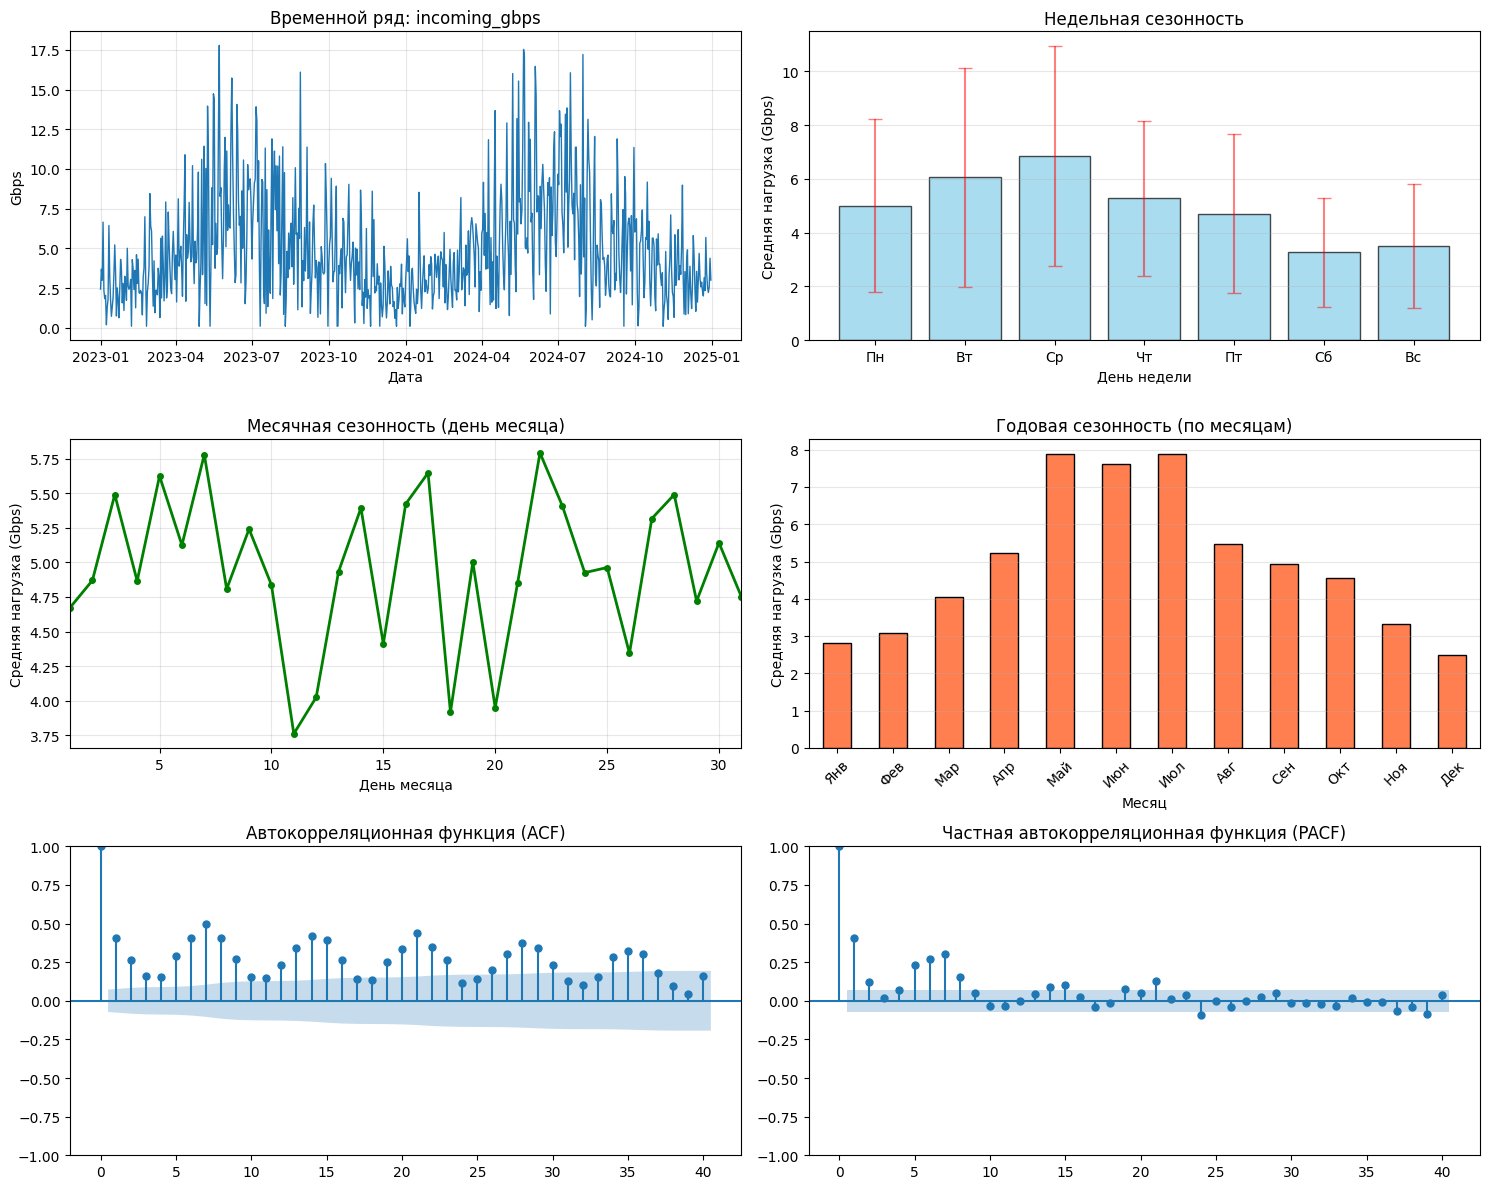

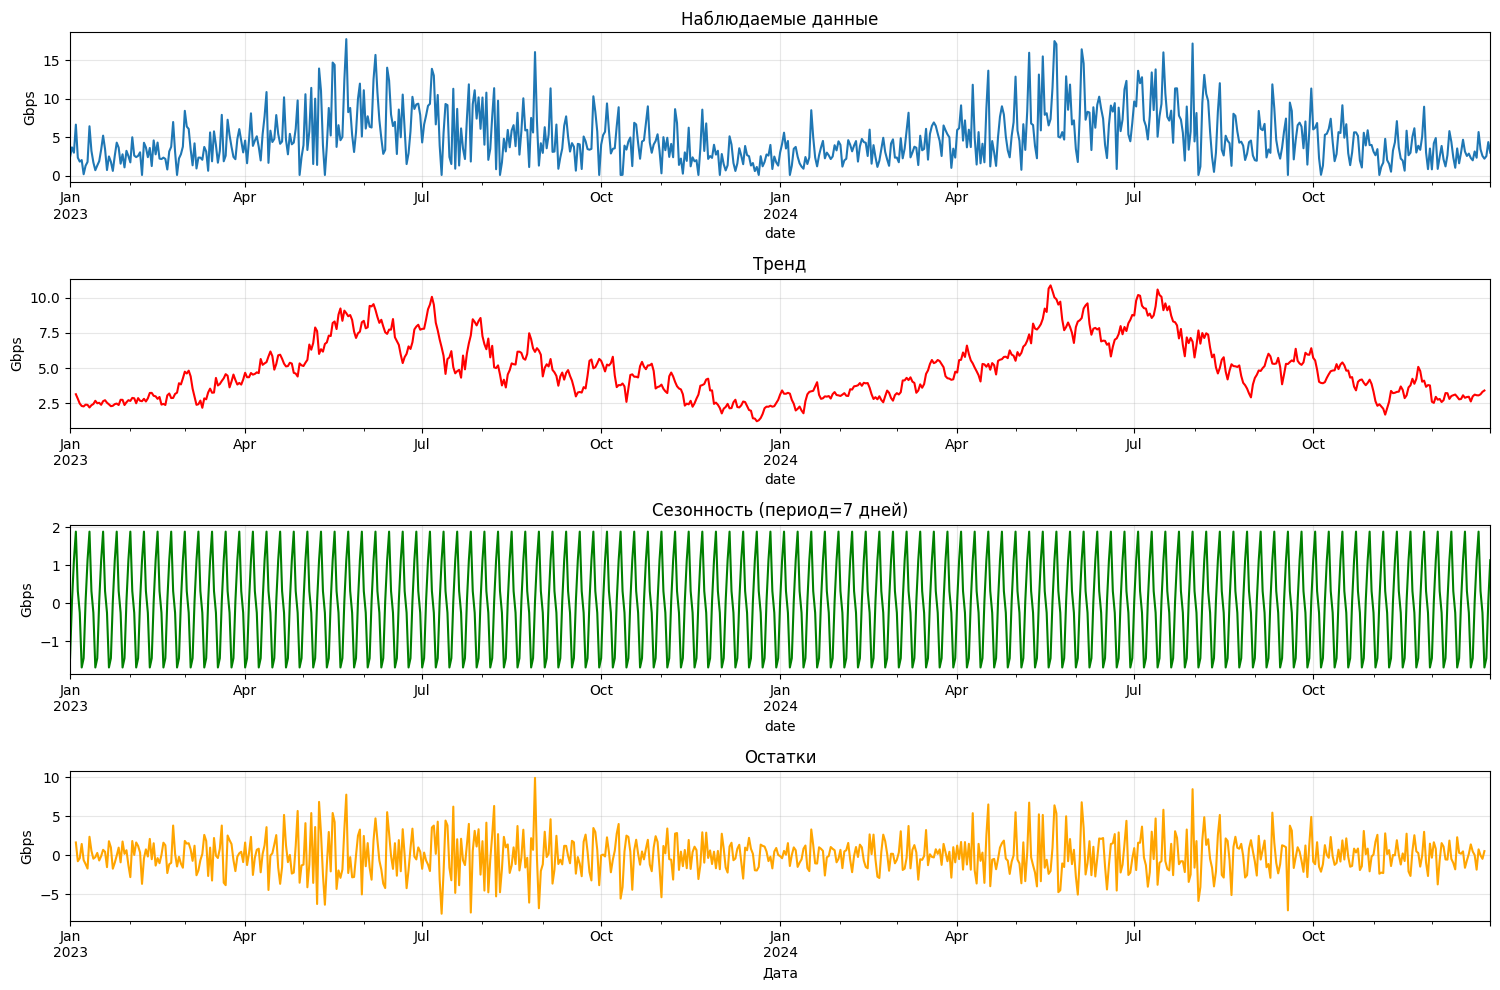


 Статистика компонент разложения:
  Размах тренда: 9.640
  Размах сезонности: 3.584
  Стд. остатков: 2.379

АНАЛИЗ СЕЗОННОСТИ ДЛЯ outgoing_gbps


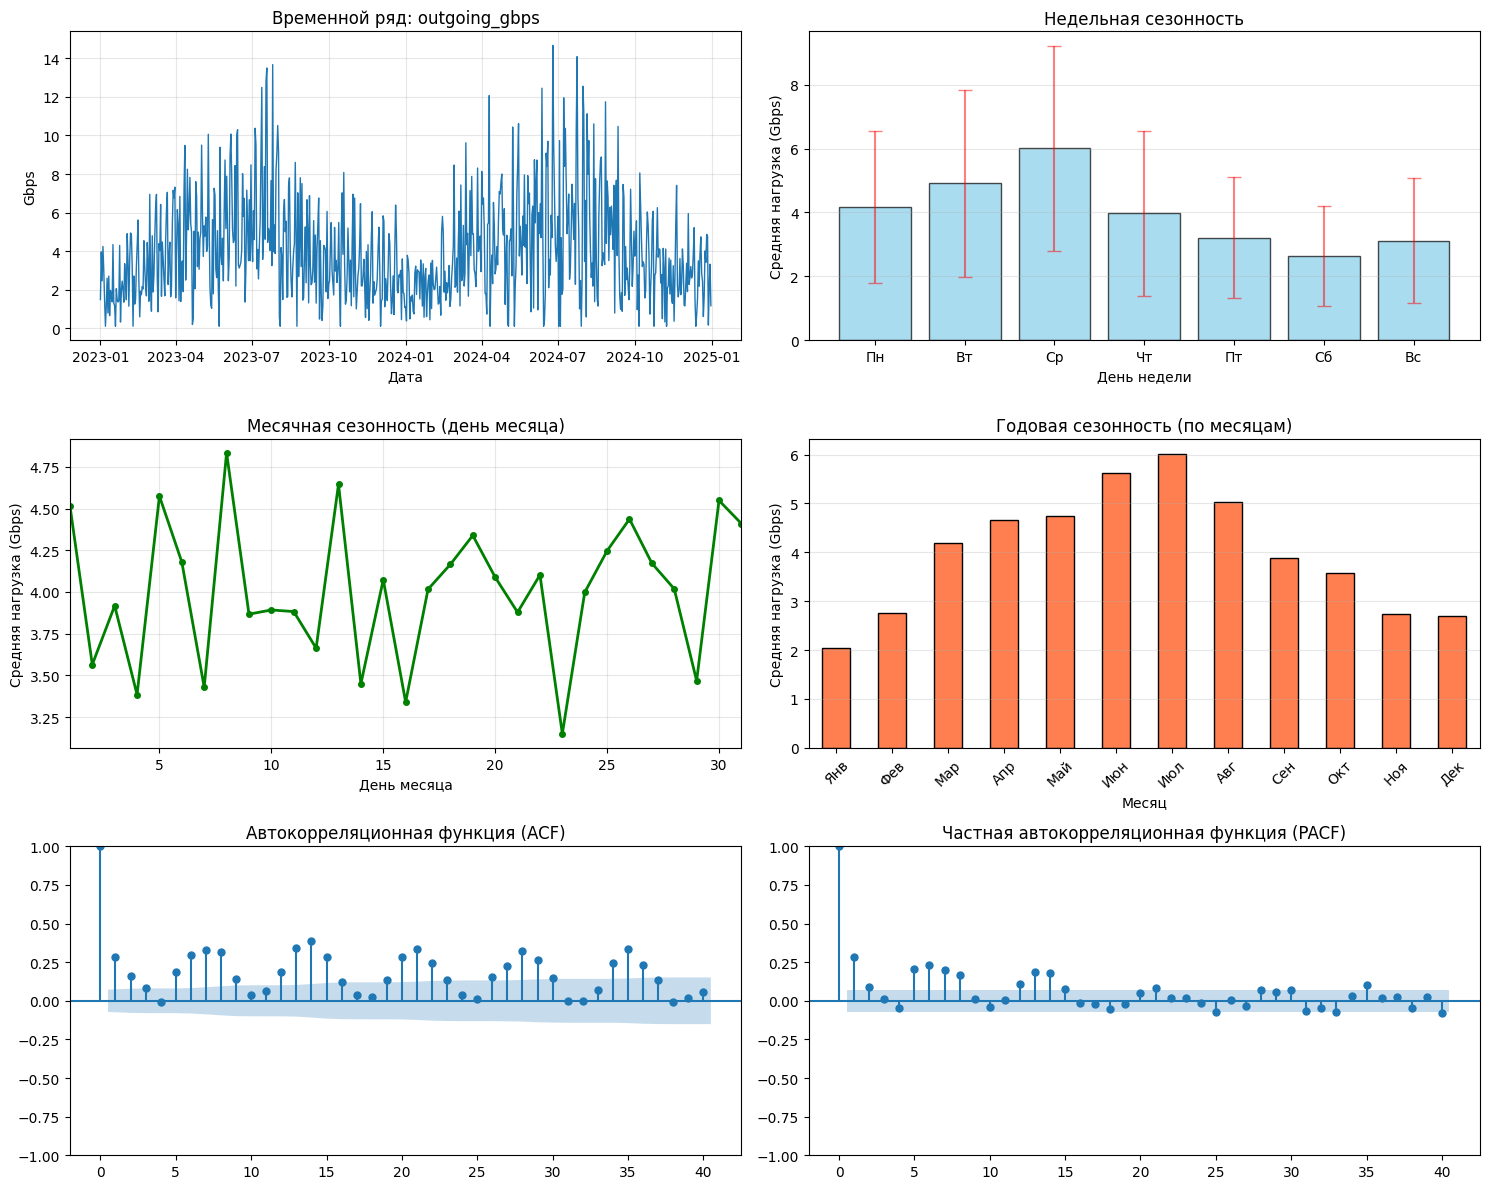

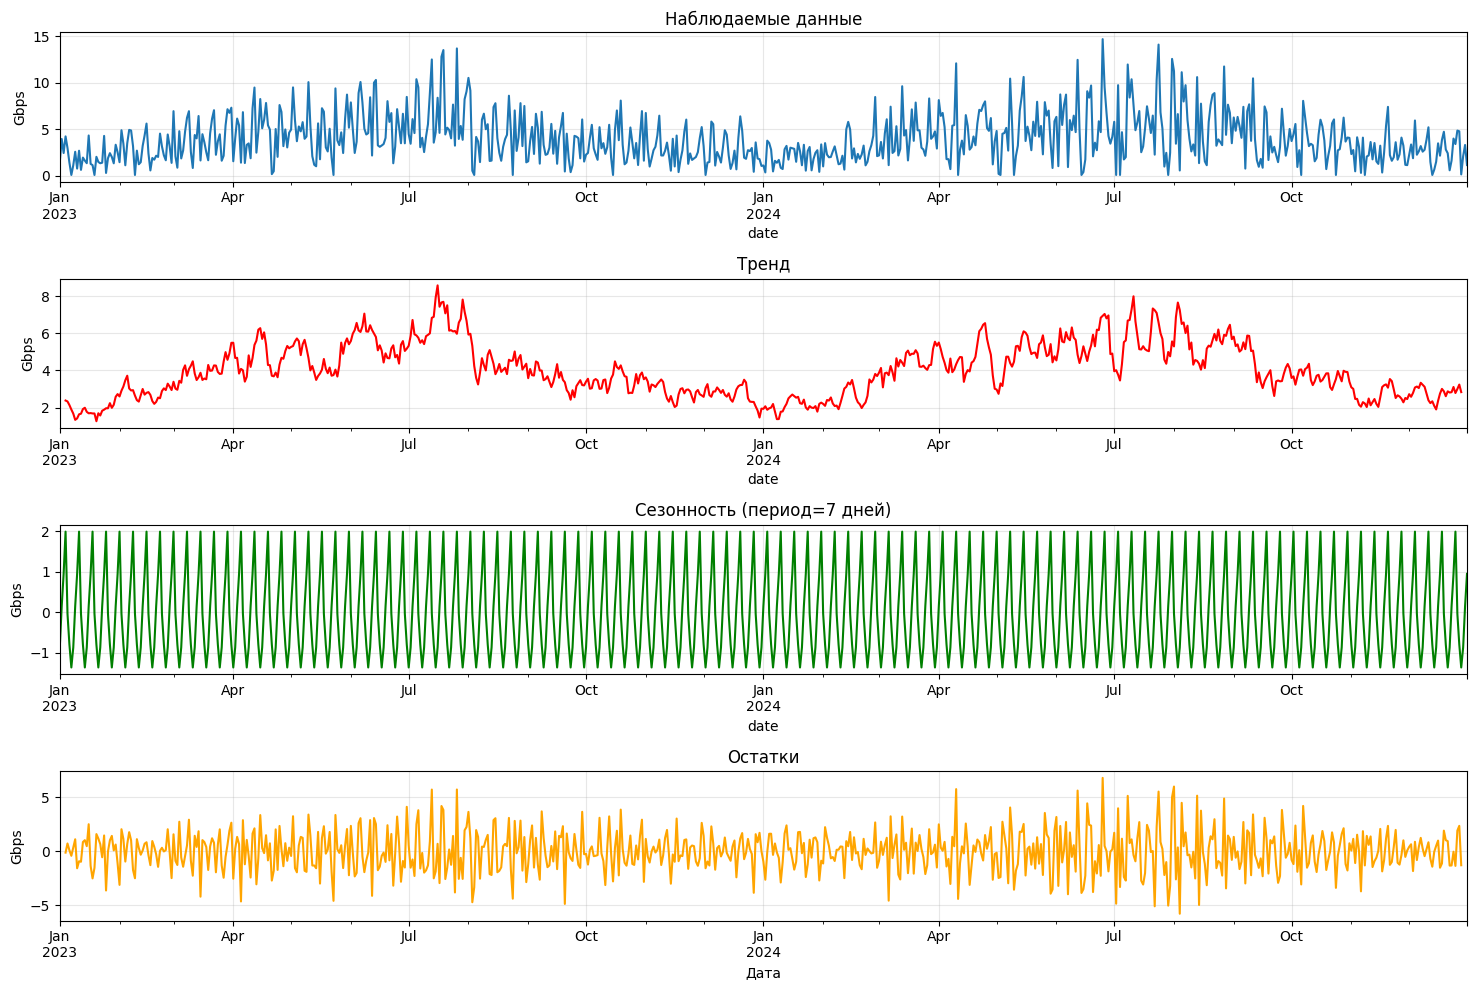


 Статистика компонент разложения:
  Размах тренда: 7.308
  Размах сезонности: 3.364
  Стд. остатков: 1.928


In [9]:
def analyze_seasonality(df, column='incoming_gbps'):
    """
    Анализирует различные типы сезонности в данных
    """
    print(f"\n{'='*70}")
    print(f"АНАЛИЗ СЕЗОННОСТИ ДЛЯ {column}")
    print(f"{'='*70}")

    df_temp = df.copy()
    df_temp = df_temp.set_index('date')

    df_temp['day_of_week'] = df_temp.index.dayofweek
    df_temp['day_of_month'] = df_temp.index.day
    df_temp['month'] = df_temp.index.month
    df_temp['quarter'] = df_temp.index.quarter
    df_temp['week_of_year'] = df_temp.index.isocalendar().week

    weekly_avg = df_temp.groupby('day_of_week')[column].mean()
    weekly_std = df_temp.groupby('day_of_week')[column].std()
    days = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

    monthly_day_avg = df_temp.groupby('day_of_month')[column].mean()

    yearly_avg = df_temp.groupby('month')[column].mean()
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))

    axes[0, 0].plot(df_temp.index, df_temp[column], linewidth=1)
    axes[0, 0].set_title(f'Временной ряд: {column}', fontsize=12)
    axes[0, 0].set_xlabel('Дата')
    axes[0, 0].set_ylabel('Gbps')
    axes[0, 0].grid(True, alpha=0.3)

    ax = axes[0, 1]
    x_pos = range(7)
    ax.bar(x_pos, weekly_avg.values, color='skyblue', alpha=0.7, edgecolor='black')
    ax.errorbar(x_pos, weekly_avg.values, yerr=weekly_std.values, fmt='none',
                ecolor='red', capsize=5, alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
    ax.set_title('Недельная сезонность', fontsize=12)
    ax.set_xlabel('День недели')
    ax.set_ylabel('Средняя нагрузка (Gbps)')
    ax.grid(True, alpha=0.3, axis='y')

    monthly_day_avg.plot(kind='line', ax=axes[1, 0], marker='o',
                         color='green', linewidth=2, markersize=4)
    axes[1, 0].set_title('Месячная сезонность (день месяца)', fontsize=12)
    axes[1, 0].set_xlabel('День месяца')
    axes[1, 0].set_ylabel('Средняя нагрузка (Gbps)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(1, 31)

    if len(yearly_avg) > 0:
        yearly_avg.plot(kind='bar', ax=axes[1, 1], color='coral', edgecolor='black')
        axes[1, 1].set_title('Годовая сезонность (по месяцам)', fontsize=12)
        axes[1, 1].set_xlabel('Месяц')
        axes[1, 1].set_ylabel('Средняя нагрузка (Gbps)')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].set_xticklabels([months[i-1] for i in yearly_avg.index], rotation=45)

    if len(df_temp) > 50:
        plot_acf(df_temp[column].dropna(), lags=min(40, len(df_temp)//2), ax=axes[2, 0])
        axes[2, 0].set_title('Автокорреляционная функция (ACF)', fontsize=12)

        plot_pacf(df_temp[column].dropna(), lags=min(40, len(df_temp)//2), ax=axes[2, 1])
        axes[2, 1].set_title('Частная автокорреляционная функция (PACF)',
                            fontsize=12)

    plt.tight_layout()
    plt.show()

    if len(df_temp) >= 14:  # Минимум 2 недели для декомпозиции
        try:
            decomposition = seasonal_decompose(df_temp[column], model='additive', period=7)

            fig, axes = plt.subplots(4, 1, figsize=(15, 10))
            decomposition.observed.plot(ax=axes[0])
            axes[0].set_title('Наблюдаемые данные', fontsize=12)
            axes[0].set_ylabel('Gbps')

            decomposition.trend.plot(ax=axes[1], color='red')
            axes[1].set_title('Тренд', fontsize=12)
            axes[1].set_ylabel('Gbps')

            decomposition.seasonal.plot(ax=axes[2], color='green')
            axes[2].set_title('Сезонность (период=7 дней)', fontsize=12)
            axes[2].set_ylabel('Gbps')

            decomposition.resid.plot(ax=axes[3], color='orange')
            axes[3].set_title('Остатки', fontsize=12)
            axes[3].set_ylabel('Gbps')
            axes[3].set_xlabel('Дата')

            for ax in axes:
                ax.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            print(f"\n Статистика компонент разложения:")
            print(f"  Размах тренда: {decomposition.trend.max() - decomposition.trend.min():.3f}")
            print(f"  Размах сезонности: {decomposition.seasonal.max() - decomposition.seasonal.min():.3f}")
            print(f"  Стд. остатков: {decomposition.resid.std():.3f}")

        except Exception as e:
            print(f"Ошибка при декомпозиции: {e}")

analyze_seasonality(df, 'incoming_gbps')
analyze_seasonality(df, 'outgoing_gbps')

## Feature Engineering

In [10]:
def prepare_data(df):
    """
    Подготовка данных с добавлением временных признаков
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['week_of_year'] = df['date'].dt.isocalendar().week
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df

def create_lag_features(df, target_col, lags=[1, 7, 14, 30]):
    """
    Создание лаговых признаков (только для обучающей выборки)
    """
    df = df.copy()
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)

    df[f'{target_col}_rolling_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df[f'{target_col}_rolling_30'] = df[target_col].shift(1).rolling(window=30).mean()

    return df

def split_data(df, test_size=30):
    """
    Разделение на train и test
    """
    train = df.iloc[:-test_size].copy()
    test = df.iloc[-test_size:].copy()
    return train, test

## Modelling

In [12]:
class ModelBase:
    def fit(self, train_data, target_col):
        """
        Обучение модели
        """
        raise NotImplementedError()

    def predict(self, steps):
        """
        Прогноз на steps шагов вперёд
        """
        raise NotImplementedError()

    def predict_test(self, test_data):
        """
        Прогноз для тестовой выборки
        """
        raise NotImplementedError()

### SARIMA

In [13]:
class SARIMAModel(ModelBase):
    def __init__(self, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.model = None
        self.model_fit = None

    def fit(self, train_data, target_col):
        print(f"Обучение SARIMA для {target_col}...")
        self.model = SARIMAX(
            train_data[target_col],
            order=self.order,
            seasonal_order=self.seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        self.model_fit = self.model.fit(disp=False)
        print(f"SARIMA обучена для {target_col}")
        return self

    def predict(self, steps):
        forecast = self.model_fit.forecast(steps=steps)
        return forecast.values

    def predict_test(self, test_data):
        return self.predict(len(test_data))


### Catboost

In [21]:
class CatBoostModel(ModelBase):
    def __init__(self):
        self.model = None
        self.feature_cols = None
        self.target_col = None
        self.last_train_data = None

    def fit(self, train_data, target_col):
        """
        Обучение CatBoost модели
        """
        print(f"Обучение CatBoost для {target_col}...")

        # Создаём лаговые признаки
        train_with_lags = create_lag_features(train_data.copy(), target_col)
        train_with_lags = train_with_lags.dropna()

        # Признаки для модели
        self.feature_cols = [
            'day_of_week', 'day_of_month', 'month', 'quarter',
            'week_of_year', 'is_weekend',
            'day_of_week_sin', 'day_of_week_cos',
            'month_sin', 'month_cos',
            f'{target_col}_lag_1', f'{target_col}_lag_7',
            f'{target_col}_lag_14', f'{target_col}_lag_30',
            f'{target_col}_rolling_7', f'{target_col}_rolling_30'
        ]

        self.target_col = target_col
        self.last_train_data = train_data.copy()

        X_train = train_with_lags[self.feature_cols]
        y_train = train_with_lags[target_col]

        self.model = CatBoostRegressor(
            iterations=1000,
            learning_rate=0.03,
            depth=6,
            loss_function='RMSE',
            verbose=False,
            random_seed=42
        )

        self.model.fit(X_train, y_train)
        print(f"CatBoost обучена для {target_col}")
        return self

    def predict_test(self, test_data):
        """
        Прогноз для тестовой выборки (рекурсивный)
        """
        predictions = []

        # Объединяем train и test для создания лагов
        full_data = pd.concat([self.last_train_data, test_data]).reset_index(drop=True)

        for i in range(len(test_data)):
            test_idx = len(self.last_train_data) + i

            # Создаём временный датафрейм с данными до текущего момента
            temp_data = full_data.iloc[:test_idx + 1].copy()
            temp_with_lags = create_lag_features(temp_data, self.target_col)

            # Берём последнюю строку для предсказания
            X_test = temp_with_lags.iloc[-1:][self.feature_cols]

            pred = self.model.predict(X_test)[0]
            predictions.append(pred)

            # Обновляем значение в full_data для следующей итерации
            full_data.loc[test_idx, self.target_col] = pred

        return np.array(predictions)

    def predict_future(self, last_date, steps):
        """
        Прогноз в будущее без реальных значений
        """
        predictions = []

        # Создаём будущие даты
        future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=steps, freq='D')
        future_df = pd.DataFrame({'date': future_dates})
        future_df = prepare_data(future_df)

        # Инициализируем колонку таргета
        future_df[self.target_col] = np.nan

        # Объединяем с историческими данными
        full_data = pd.concat([self.last_train_data, future_df]).reset_index(drop=True)

        for i in range(steps):
            future_idx = len(self.last_train_data) + i

            # Создаём лаги на основе всех данных до текущего момента
            temp_data = full_data.iloc[:future_idx + 1].copy()
            temp_with_lags = create_lag_features(temp_data, self.target_col)

            X_pred = temp_with_lags.iloc[-1:][self.feature_cols]

            pred = self.model.predict(X_pred)[0]
            predictions.append(pred)

            # Обновляем для следующей итерации
            full_data.loc[future_idx, self.target_col] = pred

        return np.array(predictions), future_dates

## Prophet

In [15]:
class ProphetModel(ModelBase):
    def __init__(self):
        self.model = None
        self.target_col = None

    def fit(self, train_data, target_col):
        print(f"Обучение Prophet для {target_col}...")

        # Подготовка данных для Prophet
        prophet_df = train_data[['date', target_col]].copy()
        prophet_df.columns = ['ds', 'y']

        self.target_col = target_col

        # Настройка модели с учётом сезонностей
        self.model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=True,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05
        )

        # Добавляем дополнительные сезонности
        self.model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

        self.model.fit(prophet_df)
        print(f"Prophet обучена для {target_col}")
        return self

    def predict_test(self, test_data):
        future = pd.DataFrame({'ds': test_data['date']})
        forecast = self.model.predict(future)
        return forecast['yhat'].values

    def predict_future(self, steps):
        future = self.model.make_future_dataframe(periods=steps, freq='D')
        forecast = self.model.predict(future)
        return forecast['yhat'].values[-steps:]

## Model Evaluation

In [17]:
def evaluate_model(y_true, y_pred, model_name, target_col):
    """
    Вычисление метрик качества
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{model_name} - {target_col}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'model': model_name, 'target': target_col,
            'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

## Pipeline

In [18]:
def train_and_evaluate_all_models(df, test_size=30):
    """
    Обучение и оценка всех моделей для обоих таргетов
    """
    # Подготовка данных
    df_prepared = prepare_data(df)
    train, test = split_data(df_prepared, test_size)

    targets = ['incoming_gbps', 'outgoing_gbps']
    models_dict = {target: {} for target in targets}
    results = []

    for target in targets:
        print(f"\n{'='*60}")
        print(f"Обработка таргета: {target}")
        print(f"{'='*60}")

        # SARIMA
        sarima = SARIMAModel(order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
        sarima.fit(train, target)
        sarima_pred = sarima.predict_test(test)
        models_dict[target]['sarima'] = sarima
        results.append(evaluate_model(test[target].values, sarima_pred, 'SARIMA', target))

        # CatBoost
        catboost = CatBoostModel()
        catboost.fit(train, target)
        catboost_pred = catboost.predict_test(test)
        models_dict[target]['catboost'] = catboost
        results.append(evaluate_model(test[target].values, catboost_pred, 'CatBoost', target))

        # Prophet
        prophet = ProphetModel()
        prophet.fit(train, target)
        prophet_pred = prophet.predict_test(test)
        models_dict[target]['prophet'] = prophet
        results.append(evaluate_model(test[target].values, prophet_pred, 'Prophet', target))

    results_df = pd.DataFrame(results)
    return models_dict, results_df, train, test

## Visualizations

In [25]:
def plot_predictions(train, test, models_dict, target):
    """
    Визуализация прогнозов всех моделей
    """
    plt.figure(figsize=(15, 6))

    # Исторические данные
    history = train.tail(60)
    plt.plot(history['date'], history[target], label='Train', color='blue', alpha=0.6)
    plt.plot(test['date'], test[target], label='Test (actual)', color='green', linewidth=2)

    # Прогнозы моделей
    sarima_pred = models_dict[target]['sarima'].predict_test(test)
    catboost_pred = models_dict[target]['catboost'].predict_test(test)
    prophet_pred = models_dict[target]['prophet'].predict_test(test)

    plt.plot(test['date'], sarima_pred, label='SARIMA', linestyle='--', linewidth=2)
    plt.plot(test['date'], catboost_pred, label='CatBoost', linestyle='--', linewidth=2)
    plt.plot(test['date'], prophet_pred, label='Prophet', linestyle='--', linewidth=2)

    plt.xlabel('Date')
    plt.ylabel(target)
    plt.title(f'Прогнозы моделей для {target}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_future_predictions(models_dict, train, target, future_days=30):
    """
    Визуализация прогнозов в будущее
    """
    last_date = train['date'].max()

    # Прогнозы
    sarima_future = models_dict[target]['sarima'].predict(future_days)
    catboost_future, future_dates = models_dict[target]['catboost'].predict_future(last_date, future_days)
    prophet_future = models_dict[target]['prophet'].predict_future(future_days)

    plt.figure(figsize=(15, 6))

    # Последние 60 дней истории
    history = train.tail(60)
    plt.plot(history['date'], history[target], label='History', color='blue', alpha=0.6)

    # Прогнозы в будущее
    plt.plot(future_dates, sarima_future, label='SARIMA', linestyle='--', linewidth=2, marker='o')
    plt.plot(future_dates, catboost_future, label='CatBoost', linestyle='--', linewidth=2, marker='s')
    plt.plot(future_dates, prophet_future, label='Prophet', linestyle='--', linewidth=2, marker='^')

    plt.axvline(x=last_date, color='red', linestyle=':', label='Forecast start')
    plt.xlabel('Date')
    plt.ylabel(target)
    plt.title(f'Прогноз на {future_days} дней вперёд для {target}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Execution


Обработка таргета: incoming_gbps
Обучение SARIMA для incoming_gbps...
SARIMA обучена для incoming_gbps

SARIMA - incoming_gbps:
  MAE:  1.4781
  RMSE: 1.8847
  R2:   -0.2450
  MAPE: 143.59%
Обучение CatBoost для incoming_gbps...
CatBoost обучена для incoming_gbps


DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdrgeuca/yvw0co0d.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdrgeuca/wh1s2jpd.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27082', 'data', 'file=/tmp/tmpjdrgeuca/yvw0co0d.json', 'init=/tmp/tmpjdrgeuca/wh1s2jpd.json', 'output', 'file=/tmp/tmpjdrgeuca/prophet_modelccw143ko/prophet_model-20251122162639.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:26:39 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:26:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



CatBoost - incoming_gbps:
  MAE:  1.4502
  RMSE: 1.8639
  R2:   -0.2177
  MAPE: 101.75%
Обучение Prophet для incoming_gbps...
Prophet обучена для incoming_gbps

Prophet - incoming_gbps:
  MAE:  1.3975
  RMSE: 1.8544
  R2:   -0.2053
  MAPE: 135.54%

Обработка таргета: outgoing_gbps
Обучение SARIMA для outgoing_gbps...
SARIMA обучена для outgoing_gbps

SARIMA - outgoing_gbps:
  MAE:  1.3472
  RMSE: 1.6858
  R2:   -0.2176
  MAPE: 208.74%
Обучение CatBoost для outgoing_gbps...
CatBoost обучена для outgoing_gbps


DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdrgeuca/cz_en103.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdrgeuca/nrt7mzdw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=77933', 'data', 'file=/tmp/tmpjdrgeuca/cz_en103.json', 'init=/tmp/tmpjdrgeuca/nrt7mzdw.json', 'output', 'file=/tmp/tmpjdrgeuca/prophet_model2ej0zusd/prophet_model-20251122162642.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:26:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:26:42 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



CatBoost - outgoing_gbps:
  MAE:  1.1197
  RMSE: 1.3859
  R2:   0.1770
  MAPE: 165.10%
Обучение Prophet для outgoing_gbps...
Prophet обучена для outgoing_gbps

Prophet - outgoing_gbps:
  MAE:  1.1450
  RMSE: 1.4657
  R2:   0.0795
  MAPE: 164.44%

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
   model        target      MAE     RMSE        R2       MAPE
  SARIMA incoming_gbps 1.478117 1.884686 -0.244998 143.594373
CatBoost incoming_gbps 1.450193 1.863901 -0.217689 101.745273
 Prophet incoming_gbps 1.397536 1.854404 -0.205311 135.538801
  SARIMA outgoing_gbps 1.347200 1.685807 -0.217649 208.738652
CatBoost outgoing_gbps 1.119708 1.385911  0.177042 165.099531
 Prophet outgoing_gbps 1.145016 1.465738  0.079510 164.439611

Визуализация для incoming_gbps...


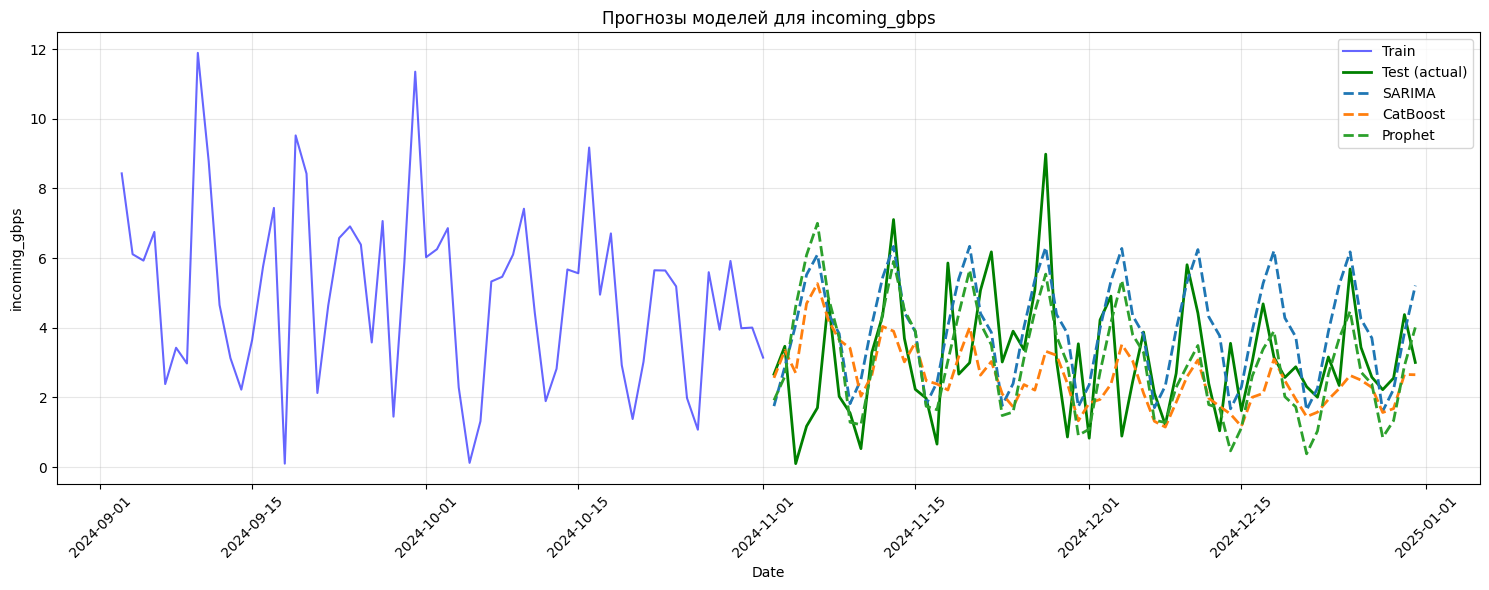

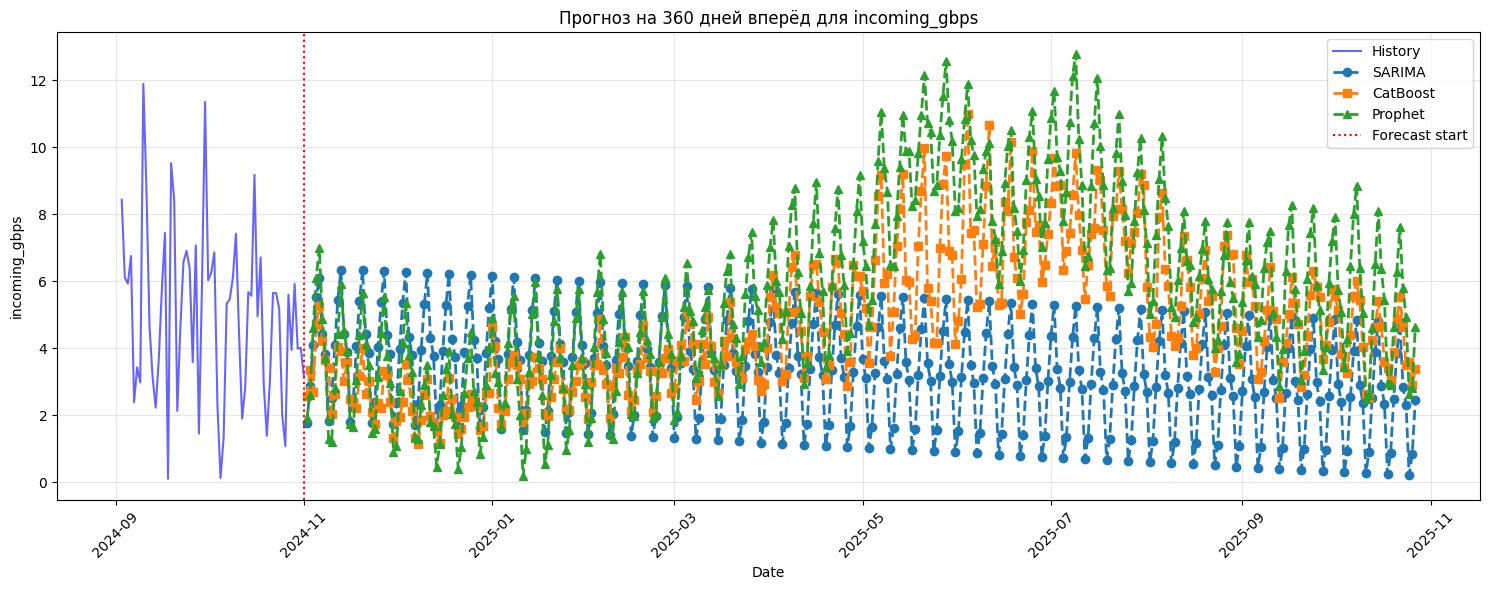


Визуализация для outgoing_gbps...


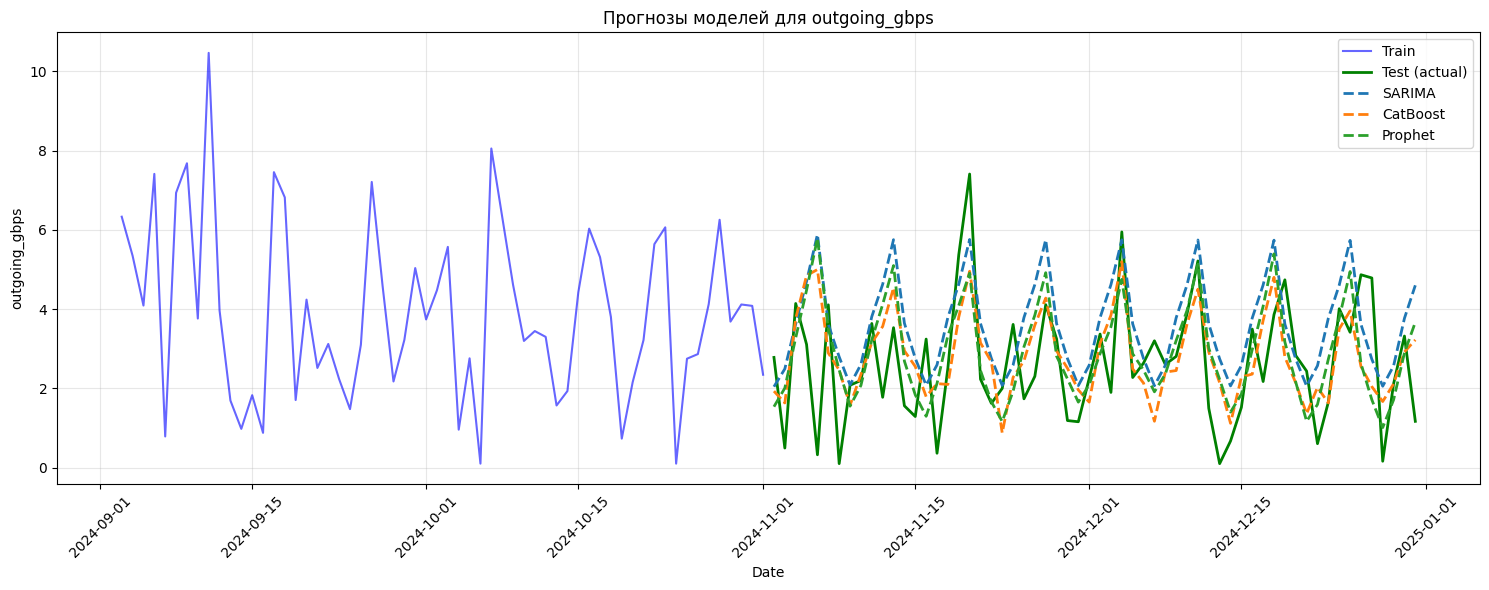

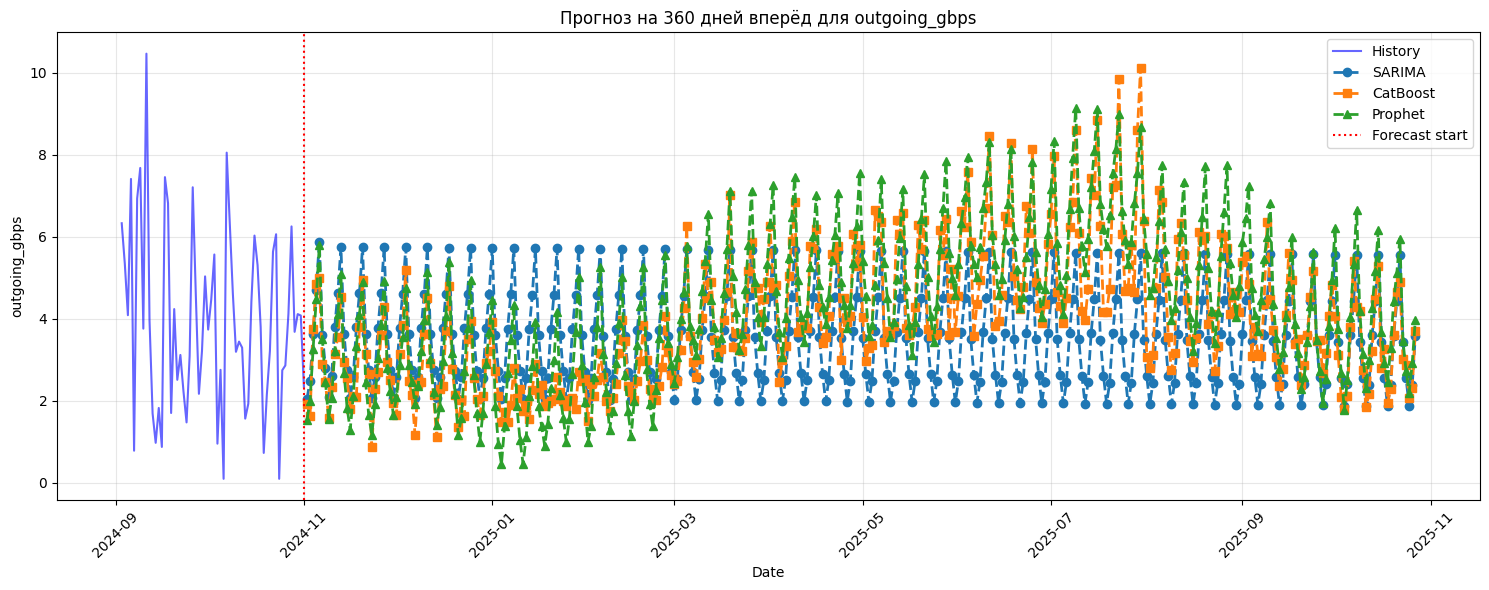


ПРОГНОЗ НА 365 ДНЕЙ ВПЕРЁД (CatBoost)


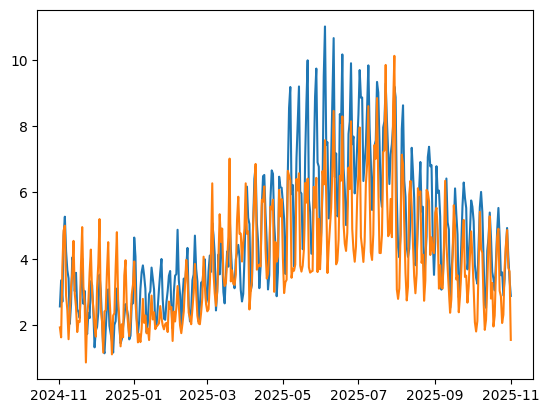

In [30]:
if __name__ == "__main__":
    # Загрузка данных
    df = pd.read_csv('network_load.csv', converters={'date': pd.to_datetime})
    df = df.sort_values('date').reset_index(drop=True)

    # Обучение и оценка всех моделей
    models_dict, results_df, train, test = train_and_evaluate_all_models(df, test_size=60)

    # Вывод сводной таблицы результатов
    print("\n" + "="*60)
    print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
    print("="*60)
    print(results_df.to_string(index=False))

    # Визуализация для incoming_gbps
    print("\nВизуализация для incoming_gbps...")
    plot_predictions(train, test, models_dict, 'incoming_gbps')
    plot_future_predictions(models_dict, train, 'incoming_gbps', future_days=360)

    # Визуализация для outgoing_gbps
    print("\nВизуализация для outgoing_gbps...")
    plot_predictions(train, test, models_dict, 'outgoing_gbps')
    plot_future_predictions(models_dict, train, 'outgoing_gbps', future_days=360)

    # Пример прогноза в будущее для лучшей модели
    print("\n" + "="*60)
    print("ПРОГНОЗ НА 365 ДНЕЙ ВПЕРЁД (CatBoost)")
    print("="*60)

    for target in ['incoming_gbps', 'outgoing_gbps']:
        predictions, dates = models_dict[target]['catboost'].predict_future(
            train['date'].max(),
            steps=365
        )

        plt.plot(dates, predictions)

        # Сохраняем модель в файл
        models_dict[target]['catboost'].model.save_model(f'{target}_forecast_model.cbm')
